In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class SparseTPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using variational inference.
    This model uses M inducing points to approximate the full process, reducing
    complexity from O(N^3) to O(NM^2), making it suitable for larger datasets.
    The implementation is based on the hierarchical Gaussian-Gamma mixture formulation
    described in the provided paper.
    The inducing point locations Z are treated as learnable hyperparameters.
    """
    def __init__(self, X, y, Z, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        
        # --- Inducing points Z are now a learnable parameter ---
        self.Z = nn.Parameter(Z) # Inducing point locations

        self.N, self.D = X.shape
        self.M, _ = Z.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # q(u) = N(u | m_u, S_u)
        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M) # Store full covariance for u

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i) for i=1..N
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, Kzz_inv, Kxz):
        """CAVI update for q(lambda_i), based on Eq. (1) and (2) in the paper."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()

        # Calculate E[f_i] and Var(f_i) based on q(u) (Section 5.1)
        # E_q[f_i] = k_iZ @ K_ZZ^-1 @ m_u
        Kzz_inv_mu = Kzz_inv @ self.m_u
        E_q_f = Kxz @ Kzz_inv_mu

        # Var_q(f_i) = E[r^-1](k_ii - k_iZ K_ZZ^-1 k_Zi) + k_iZ K_ZZ^-1 S_u K_ZZ^-1 k_Zi
        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        Kxx_diag = self.kernel(self.X, self.X).diag()
        Kxz_Kzz_inv = Kxz @ Kzz_inv
        
        var_term1 = E_inv_r * (Kxx_diag - (Kxz_Kzz_inv * Kxz).sum(dim=1))
        
        Kxz_Kzz_inv_Su = Kxz_Kzz_inv @ self.S_u
        var_term2 = (Kxz_Kzz_inv_Su * Kxz_Kzz_inv).sum(dim=1)
        
        Var_q_f = (var_term1 + var_term2).unsqueeze(1)

        # E[(y_i - f_i)^2] = (y_i - E[f_i])^2 + Var(f_i)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        # Update alpha_lambda and beta_lambda (Eq. 1 & 2)
        self.alpha_lambda = nu_e / 2.0 + 0.5
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Kzz_inv):
        """CAVI update for q(r), based on Eq. (3) and (4) in the paper."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        
        # E[u^T K_ZZ^-1 u] = Tr(K_ZZ^-1 S_u) + m_u^T K_ZZ^-1 m_u (Section 5.2)
        Kzz_inv_Su = Kzz_inv @ self.S_u
        trace_term = torch.trace(Kzz_inv_Su)
        quad_form_term = self.m_u.T @ Kzz_inv @ self.m_u
        E_quad_form_u = trace_term + quad_form_term

        # Update alpha_r and beta_r (Eq. 3 & 4)
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz_inv, Kxz):
        """CAVI update for q(u), based on Section 4.3 in the paper."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # Calculate precision matrix S_u^-1 (Eq. on page 5)
        # S_u^-1 = E[r]K_ZZ^-1 + K_ZZ^-1 (sum_i E[lambda_i]/sigma^2 k_Zi k_iZ) K_ZZ^-1
        # A more stable way is:
        # S_u^-1 = E[r]K_ZZ^-1 + sum_i( (E[lambda_i]/sigma^2) * (K_ZZ^-1 k_Zi) @ (k_iZ K_ZZ^-1) )
        weighted_Kxz = Kxz.T * (E_lambda.squeeze() / sigma_sq) # (M, N)
        B = weighted_Kxz @ Kxz # (M, M)
        S_u_inv = E_r * Kzz_inv + Kzz_inv @ B @ Kzz_inv
        
        # S_u = (S_u^-1)^-1
        # Use Cholesky for stable inversion
        L_inv = torch.linalg.cholesky(S_u_inv)
        self.S_u = torch.cholesky_inverse(L_inv)

        # Calculate mean m_u (Eq. on page 5)
        # m_u = S_u @ K_ZZ^-1 @ sum_i( (E[lambda_i]/sigma^2) * k_Zi * y_i )
        temp_vec = weighted_Kxz @ self.y # (M, 1)
        self.m_u = self.S_u @ Kzz_inv @ temp_vec
        
    def _cavi_step(self, Kzz, Kxz, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        Kzz_inv = torch.inverse(Kzz)
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # CAVI updates in order
            self._update_q_lambda(Kzz_inv, Kxz)
            self._update_q_r(Kzz_inv)
            self._update_q_u(Kzz_inv, Kxz)

            # Check for convergence
            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kzz, Lzz, Kxz):
        """
        Calculates the Evidence Lower Bound (ELBO) for the sparse model.
        Based on the final form in Section 8.3 of the paper.
        L(q) = E_q[log p(y|f)] - KL(q(u)q(r)||p(u,r)) - sum(KL(q(lambda_i)||p(lambda_i)))
        """
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        Kzz_inv = torch.cholesky_inverse(Lzz)

        # --- 1. Expected Log Likelihood ---
        # This term is the same as in _update_q_lambda
        Kzz_inv_mu = Kzz_inv @ self.m_u
        E_q_f = Kxz @ Kzz_inv_mu
        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        Kxx_diag = self.kernel(self.X, self.X).diag()
        Kxz_Kzz_inv = Kxz @ Kzz_inv
        var_term1 = E_inv_r * (Kxx_diag - (Kxz_Kzz_inv * Kxz).sum(dim=1))
        Kxz_Kzz_inv_Su = Kxz_Kzz_inv @ self.S_u
        var_term2 = (Kxz_Kzz_inv_Su * Kxz_Kzz_inv).sum(dim=1)
        Var_q_f = (var_term1 + var_term2).unsqueeze(1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        # KL(q(u)q(r) || p(u,r)) = E_q[log q(u)] + E_q[log q(r)] - E_q[log p(u|r)] - E_q[log p(r)]
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(u) (Entropy of Gaussian)
        log_det_Su = torch.linalg.slogdet(self.S_u)[1]
        log_q_u = -0.5 * self.M * (1 + math.log(2 * math.pi)) - 0.5 * log_det_Su

        # log q(r) (Entropy of Gamma)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(u|r)]
        Kzz_inv_Su = Kzz_inv @ self.S_u
        trace_term = torch.trace(Kzz_inv_Su)
        quad_form_term = self.m_u.T @ Kzz_inv @ self.m_u
        E_quad_form_u = trace_term + quad_form_term
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        E_log_p_u_r = -0.5 * self.M * math.log(2 * math.pi) + 0.5 * self.M * E_log_r - 0.5 * log_det_Kzz - 0.5 * E_r * E_quad_form_u

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - E_log_p_u_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda
        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        """
        print("Starting optimization for sparse model (with learnable inducing points)...")
        pbar = tqdm.trange(max_iter_global)

        # The optimizer now also includes self.Z as a parameter
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        for i in pbar:
            # Recompute kernels in each loop as hyperparameters (including Z) change
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Kxz = self.kernel(self.X, self.Z)

            # E-Step: Run CAVI to update variational parameters
            with torch.no_grad():
                self._cavi_step(Kzz, Kxz, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            for j in range(max_iter_local):
                optimizer.zero_grad()
                # We need to recompute kernels here because Z is being updated by the optimizer
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                neg_elbo = -self.calculate_elbo(Kzz, Lzz, Kxz)
                neg_elbo.backward()
                optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            # Precompute kernels with the final optimized inducing points
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            K_star_z = self.kernel(X_test, self.Z)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz_inv = torch.inverse(Kzz)

            # Predictive Mean (Section 5.1, applied to test points)
            # E[f_*] = k_{*Z} @ K_ZZ^-1 @ m_u
            pred_mean = K_star_z @ Kzz_inv @ self.m_u

            # Predictive Variance (Section 5.1, applied to test points)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            Ksz_Kzz_inv = K_star_z @ Kzz_inv
            
            var_term1 = E_inv_r * (K_star_star_diag - (Ksz_Kzz_inv * K_star_z).sum(dim=1))
            
            Ksz_Kzz_inv_Su = Ksz_Kzz_inv @ self.S_u
            var_term2 = (Ksz_Kzz_inv_Su * Ksz_Kzz_inv).sum(dim=1)
            
            pred_var = var_term1 + var_term2
            
            # The predictive distribution is Student-t (Section 7)
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 200 # Use more data points to see the benefit of sparse model
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.3
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 1
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:15]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0
    y_train[150] = 6.0

    # 2. Setup the sparse model
    M = 25 # Number of inducing points
    # Initialize inducing points by selecting a subset of training data
    inducing_indices = torch.randperm(N)[:M]
    Z_initial = X_train[inducing_indices].clone()

    model = SparseTPRegression(
        X=X_train,
        y=y_train,
        Z=Z_initial,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5 # A reasonable starting point
    )

    # 3. Fit the model
    model.fit(max_iter_global=1000, max_iter_local=1, lr=0.01, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 300).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1.5, alpha=0.6, label='Training Data (with outliers)')
    # Plot the final, optimized inducing point locations
    plt.plot(model.Z.detach(), torch.zeros_like(model.Z.detach())-5.5, 'b|', mew=2, markersize=12, label='Optimized Inducing Points')


    plt.title('Sparse Student-t Process Regression (with learnable inducing points)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.show()


Starting optimization for sparse model (with learnable inducing points)...


ELBO: 1754.30:  86%|████████▋ | 865/1000 [00:19<00:03, 43.52it/s]


_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 24 is not positive-definite).

Starting Variational EM optimization...
EM Iteration 50/300, ELBO: -73.3940
EM Iteration 100/300, ELBO: -51.4250
EM Iteration 150/300, ELBO: -33.6880
EM Iteration 200/300, ELBO: -21.0794
EM Iteration 250/300, ELBO: -12.0826
EM Iteration 300/300, ELBO: -6.0207

Optimization finished.

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-4.93148375 -4.59346973 -4.16620632 -3.24052913 -3.14201251 -2.21157857
 -2.08380505 -1.4716701  -0.42172578 -0.59067507  0.06197711  1.0080039
  0.88092329  2.42848741  1.77022865  3.24499231  3.05428461  4.34245813
  4.24834646  4.92612404]
-------------------


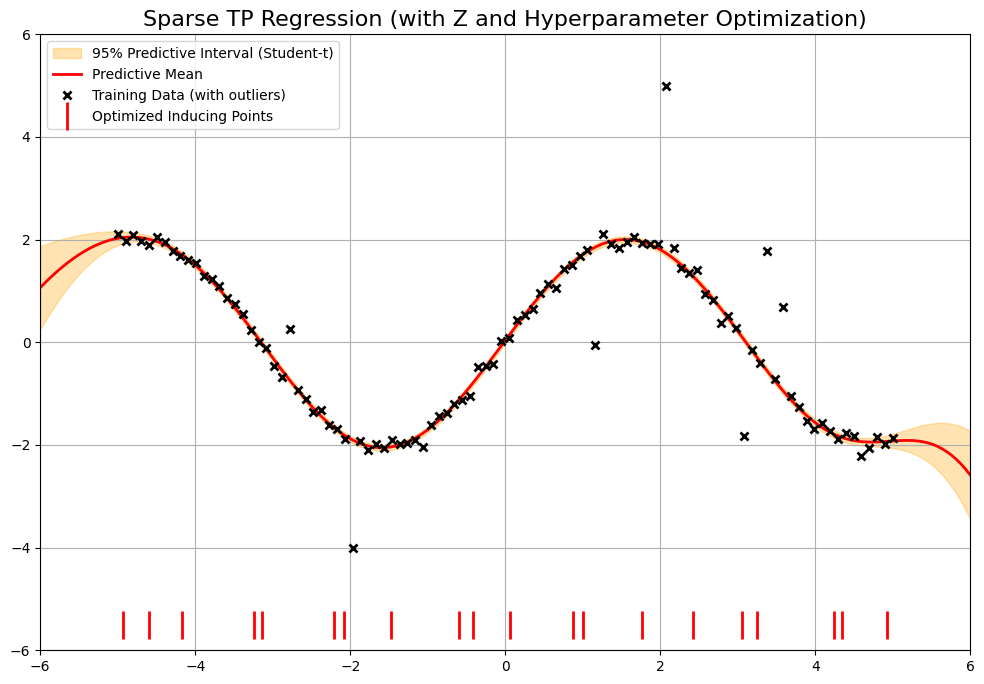

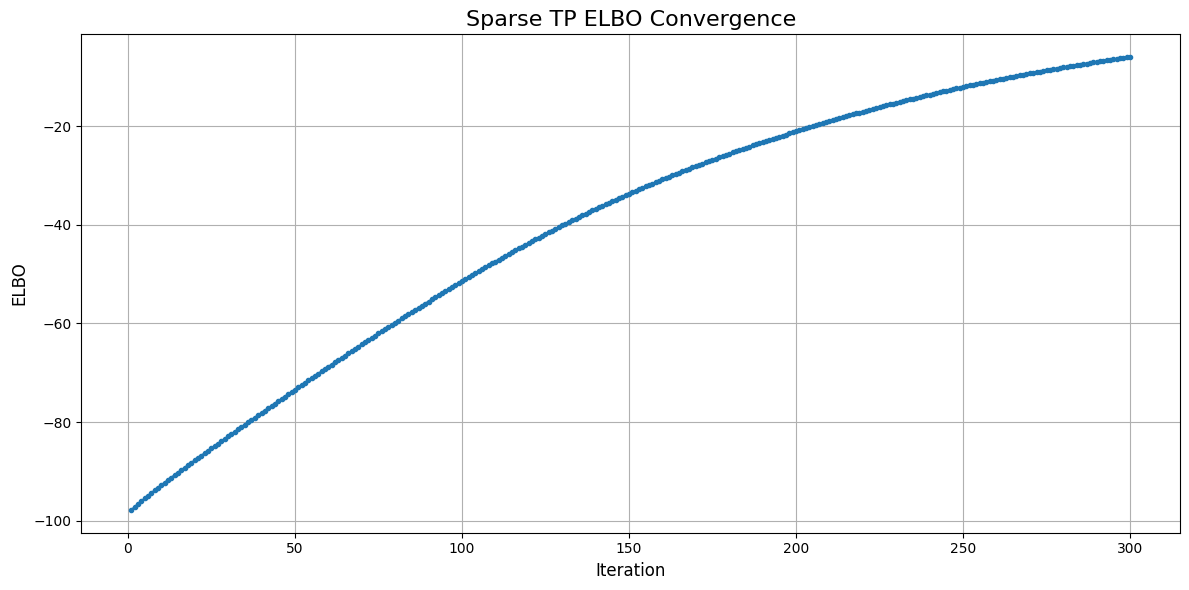

In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import t
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegression:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, Z_initial, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Initialize Hyperparameters and Inducing Points (M-step) ---
        # These are now learnable parameters. We optimize their log for stability.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(nu_e)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = torch.nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.Z = torch.nn.Parameter(Z_initial.clone())

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _e_step(self, cavi_max_iter=1):
        """Performs the CAVI updates for the variational parameters (E-Step)."""
        with torch.no_grad(): # No gradients needed for the E-step updates
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
            for _ in range(cavi_max_iter):
                # Update q(lambda)
                K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
                expected_f_mean = K_XZ @ K_ZZ_inv_m_u
                if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
                else: expected_r_inv = self.beta_r
                k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
                K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
                var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
                var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
                var_f = var_f_term1 + var_f_term2
                expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
                self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
                self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

                # Update q(r)
                trace_term = torch.trace(K_ZZ_inv @ self.S_u)
                mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
                expected_u_quadratic_form = trace_term + mean_term
                self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
                self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

                # Update q(u)
                expected_r = self.alpha_r / self.beta_r
                expected_lambda = self.alpha_lambda / self.beta_lambda
                precision_u_prior = expected_r * K_ZZ_inv
                K_ZX = K_XZ.T
                A = K_ZX * (expected_lambda / params['sigma_sq'])
                B = A @ K_XZ
                precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
                precision_u = precision_u_prior + precision_u_lik
                self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
                b = K_ZZ_inv.T @ (K_ZX @ (expected_lambda * self.y / params['sigma_sq']))
                self.m_u = (self.S_u @ b).unsqueeze(1)

    def _calculate_elbo(self):
        """Calculates the Evidence Lower Bound (ELBO) for the M-step."""
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
        K_ZZ_inv = torch.inverse(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

        # 1. Expected Log-Likelihood
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
        var_f = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1)) + \
                (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  expected_lambda / params['sigma_sq'] * expected_sq_error)

        # 2. KL Divergences
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        kl_u = 0.5 * (
            -torch.logdet(self.S_u) - self.M * expected_log_r + torch.logdet(K_ZZ) + \
            (self.alpha_r / self.beta_r) * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u) - self.M
        ).squeeze()
        
        # CORRECTED a typo here: params['nu_e'] -> params['nu_epsilon']
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo # Maximize ELBO by minimizing -ELBO
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z],
            lr=lr
        )
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        Returns the parameters of the predictive Student-t distribution.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = torch.diag(rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']))

            K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
            pred_mean = (K_star_Z @ K_ZZ_inv_m_u).squeeze()

            K_star_Z_K_ZZ_inv = K_star_Z @ K_ZZ_inv
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = gp_var * (self.beta_r / self.alpha_r)
            
            return pred_mean, pred_scale_sq, pred_nu

if __name__ == '__main__':

    torch.set_default_dtype(torch.float64)
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=300, cavi_max_iter=5, lr=0.01)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


Starting optimization for non-sparse model...


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_2750776/1577759932.py:98: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2255.)
  self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]
ELBO: 2859.93: 100%|██████████| 100/100 [00:02<00:00, 35.09it/s]


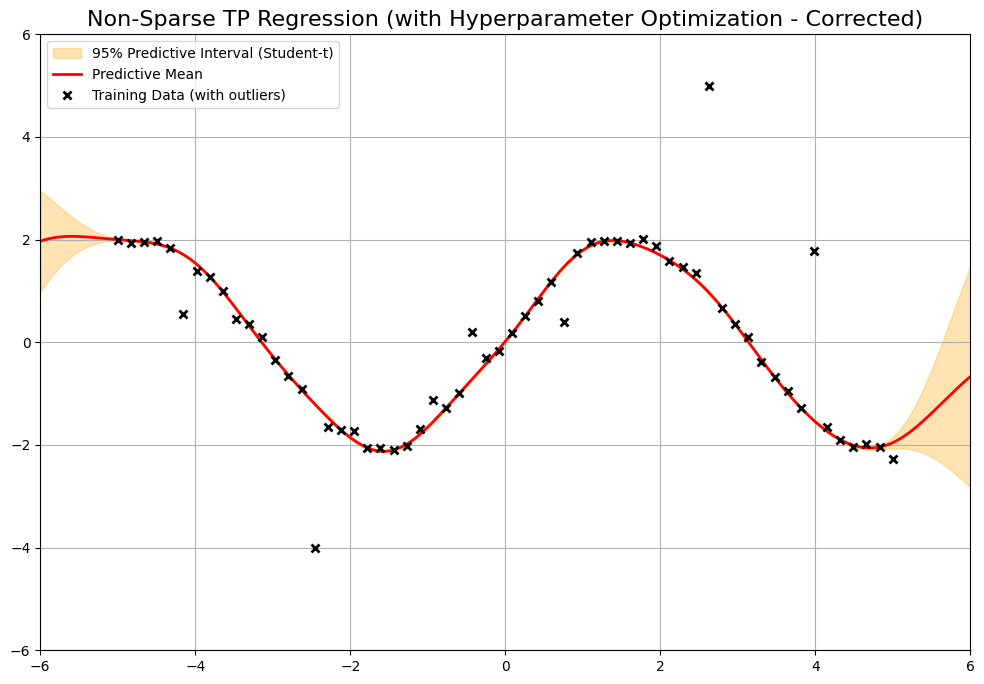

In [2]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        """
        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter_global)

        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):
                optimizer.zero_grad()
                Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx = torch.linalg.cholesky(Kxx)
                neg_elbo = -self.calculate_elbo(Kxx, Lxx)
                neg_elbo.backward()
                optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # --- CORRECTED Predictive Variance Calculation ---
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Term 1: Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            # This is the corrected part.
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Term 2: E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    torch.set_default_dtype(torch.float64)


    # 1. Generate data
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model
    model.fit(max_iter_global=100, max_iter_local=10, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization - Corrected)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.show()
